Experiment 3: House Price Prediction using Linear Regression


Aim
To predict house prices using a linear regression model.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("House Price India.csv.zip")  # change file name if needed
df.head()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810145,42491,5,2.50,3650,9050,2.0,0,4,5,...,1921,0,122003,52.8645,-114.557,2880,5400,2,58,2380000
1,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
2,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
3,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
4,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000


In [ ]:
# Remove spaces and make lowercase
df.columns = df.columns.str.strip().str.lower()

# Show all columns
print(df.columns)

Index(['id', 'date', 'number of bedrooms', 'number of bathrooms',
       'living area', 'lot area', 'number of floors', 'waterfront present',
       'number of views', 'condition of the house', 'grade of the house',
       'area of the house(excluding basement)', 'area of the basement',
       'built year', 'renovation year', 'postal code', 'lattitude',
       'longitude', 'living_area_renov', 'lot_area_renov',
       'number of schools nearby', 'distance from the airport', 'price'],
      dtype='object')


In [ ]:
target_col = "price"

In [ ]:
if target_col not in df.columns:
    print(" Column NOT found. Available columns:")
    print(df.columns)
else:
    print(" Column found:", target_col)

 Column found: price


In [ ]:
# Fill missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Convert categorical → numeric
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop(columns=[target_col])
y = df[target_col]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print(" Model trained successfully!")

 Model trained successfully!


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 105542.36193864356
MSE: 35029743918.82478
R2 Score: 0.7514192105702034


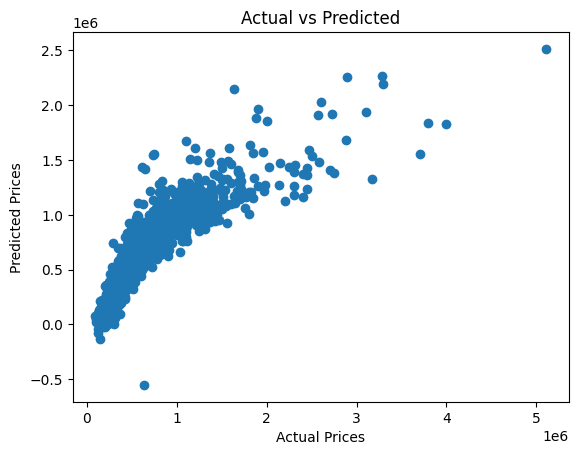

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

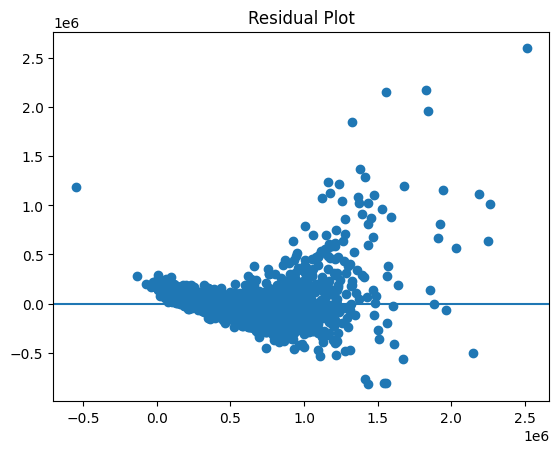

In [ ]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.title("Residual Plot")
plt.show()